# Customer Segmentation Analysis

## Objective

The objective of this project is to segment an e-commerce customer base into distinct groups based on purchasing behaviour. RFM (Recency, Frequency, Monetary) analysis and K-Means clustering are used to identify meaningful customer segments that can support targeted marketing strategies.

## 1. Importing Required Libraries

The following Python libraries are used for data manipulation, visualization, and customer segmentation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_excel(
    r"C:\Users\Vageesha Kriti\OneDrive\Desktop\OIBSIP_Data_Analytics\online+retail\Online Retail.xlsx"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Dataset Overview and Initial Inspection

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Data Quality Observations

The dataset contains transaction-level retail information. Missing values, duplicate records, cancelled transactions, and invalid quantities or prices need to be handled before creating customer-level RFM features.

## 4. Data Cleaning and Preparation

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df = df.dropna(subset=['CustomerID'])

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (392692, 8)


In [8]:
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate rows after cleaning: 0


### Cleaning Observations

Rows without CustomerID are removed because customer-level segmentation requires a valid customer identifier.

Cancelled invoices are excluded because they do not represent completed purchases.

Transactions with non-positive quantities or prices are removed because they do not represent valid sales.

Duplicate records are also removed to prevent repeated transactions from affecting customer behaviour measures.

## 5. RFM Feature Engineering

RFM analysis is used to represent customer purchasing behaviour:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique invoices made by the customer.
- **Monetary:** Total amount spent by the customer.

In [9]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## 6. Customer-Level Descriptive Statistics

In [10]:
print("Average Purchase Value:", df['TotalAmount'].mean())

print("Average Purchase Frequency:",
      rfm['Frequency'].mean())

print("Average Customer Lifetime Value:",
      rfm['Monetary'].mean())

print("\nRFM Descriptive Statistics:")
display(rfm[['Recency', 'Frequency', 'Monetary']].describe())

Average Purchase Value: 22.631499735161402
Average Purchase Frequency: 4.272014753342554
Average Customer Lifetime Value: 2048.688080682342

RFM Descriptive Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### RFM Observations

Recency indicates how recently customers purchased, Frequency represents how often customers purchased, and Monetary represents the total value generated by each customer.

These three behavioural features provide a suitable basis for customer segmentation.

## 7. RFM Feature Distributions

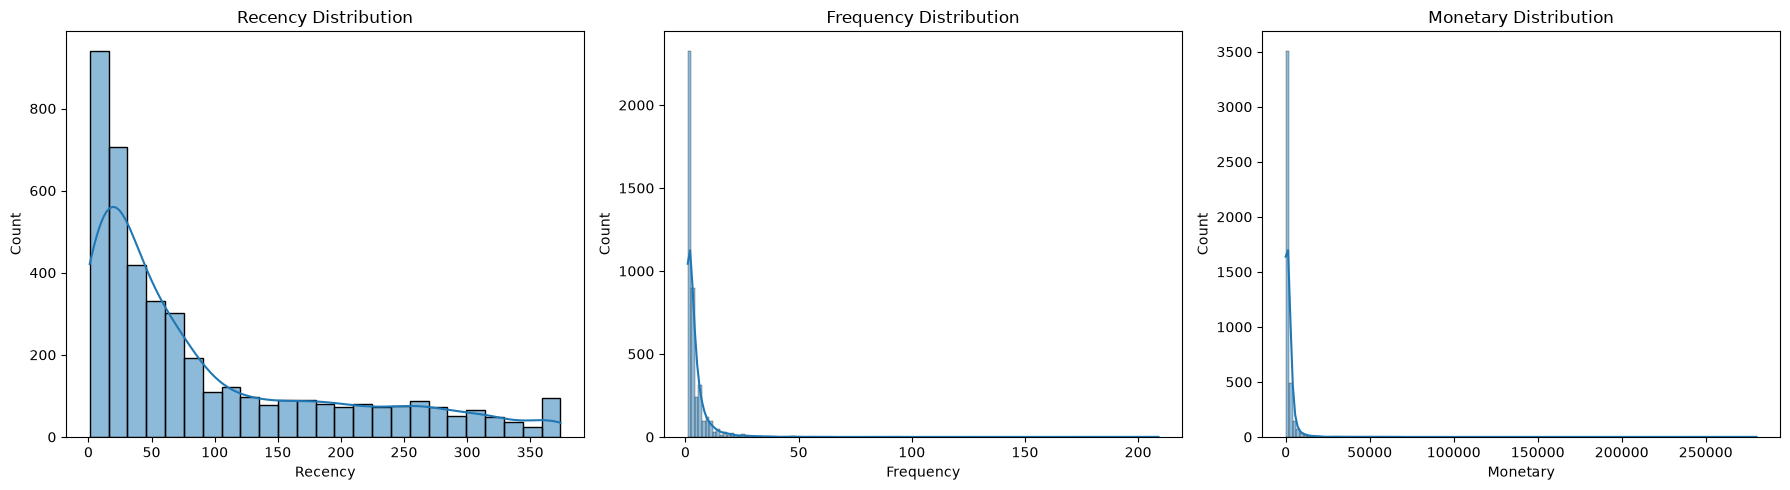

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

### Distribution Observation

The RFM distributions show differences in customer purchasing behaviour. Some customers purchase frequently and generate higher monetary value, while others purchase less frequently or have not purchased recently.

## 8. Data Standardisation

RFM features have different scales, so StandardScaler is applied before K-Means clustering. This prevents features with larger numerical ranges from dominating the clustering process.

In [12]:
features = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


## 9. Determining the Optimal Number of Clusters

The Elbow Method is used to determine a suitable number of clusters for K-Means clustering.

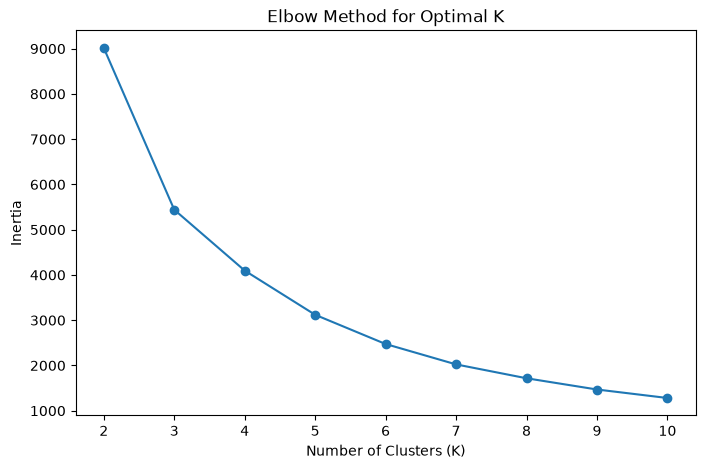

In [13]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

### Elbow Method Observation

The elbow point represents the value of K where increasing the number of clusters produces diminishing improvements in within-cluster variation.

Based on the elbow plot, **4 clusters** are selected for customer segmentation.

## 10. Applying K-Means Clustering

In [14]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


## 11. Cluster Visualisation — Recency vs Frequency

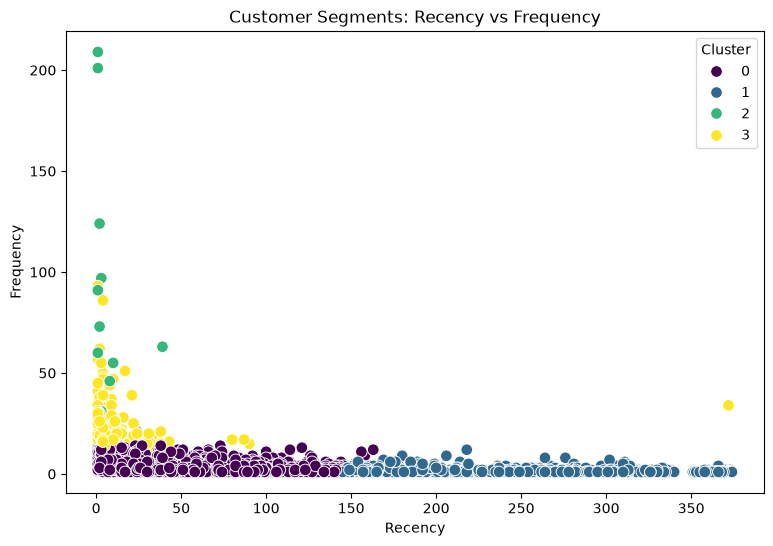

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    s=70
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend(title='Cluster')
plt.show()

### Observation

The scatter plot shows how customer segments differ according to purchase recency and purchase frequency. Customers within the same cluster exhibit relatively similar purchasing behaviour.

## 12. Cluster Visualisation — Frequency vs Monetary

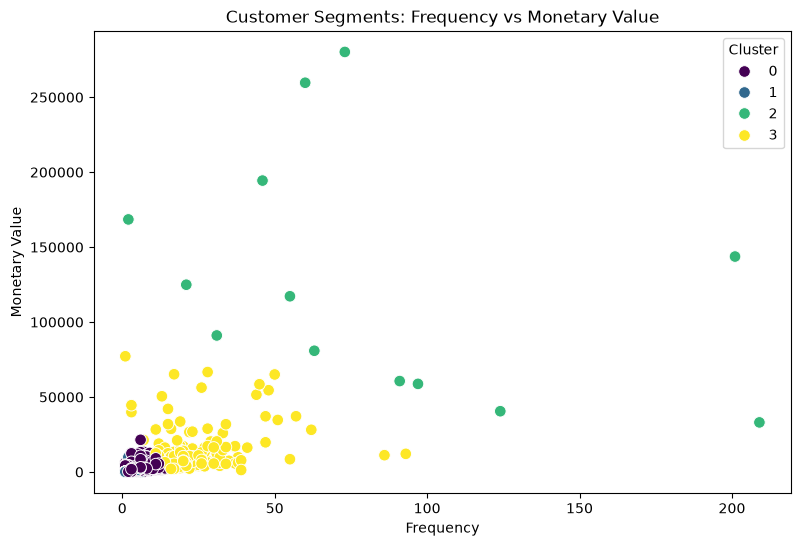

In [16]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=70
)

plt.title('Customer Segments: Frequency vs Monetary Value')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.show()

### Observation

The Frequency vs Monetary plot highlights differences in customer purchasing frequency and total spending. High-value customers can be distinguished from customers with lower purchasing activity.

## 13. Customer Segment Profiling

In [18]:
cluster_profile = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [19]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts


Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

### Segment Interpretation

Based on the average RFM values, the customer segments are interpreted as follows:

- **Cluster 0 – Occasional / Moderate Customers:** These customers have moderate recency, relatively low purchase frequency, and moderate monetary value. They represent the largest customer group.

- **Cluster 1 – At-Risk / Inactive Customers:** These customers have very high recency and low frequency and monetary value, indicating that they have not purchased recently and may be at risk of churn.

- **Cluster 2 – VIP / High-Value Customers:** These customers have very low recency, extremely high purchase frequency, and very high monetary value. They are the most valuable customers and should receive premium treatment.

- **Cluster 3 – Loyal / High-Value Customers:** These customers purchase recently, have high purchase frequency, and generate substantial monetary value. They represent loyal and valuable customers.

## 14. Number of Customers in Each Segment

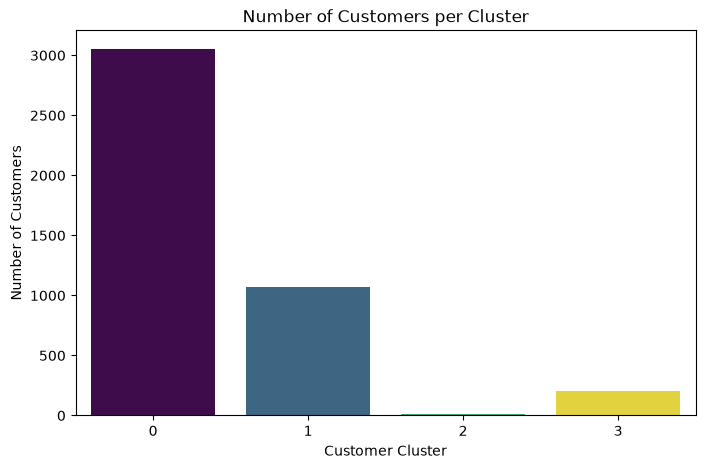

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x='Cluster',
    hue='Cluster',
    palette='viridis',
    legend=False
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')

plt.show()

### Observation

The bar chart shows the size of each customer segment. Segment sizes can help the business decide how to allocate marketing resources and design campaigns for different groups.

## 15. Marketing Insights and Recommendations

### Cluster 0 – Occasional / Moderate Customers
These customers have moderate purchasing activity and represent the largest segment.

**Recommended Marketing Actions:**
- Send personalised product recommendations.
- Offer limited-time discounts to encourage repeat purchases.
- Introduce loyalty rewards to increase purchase frequency.

### Cluster 1 – At-Risk / Inactive Customers
These customers have not purchased for a long period and have relatively low spending.

**Recommended Marketing Actions:**
- Run targeted win-back campaigns.
- Offer personalised discounts.
- Send reminders about new products and special offers.

### Cluster 2 – VIP / High-Value Customers
These customers are the most recent, frequent, and highest-spending customers.

**Recommended Marketing Actions:**
- Provide exclusive loyalty rewards.
- Offer VIP memberships and premium benefits.
- Give early access to new products.
- Provide personalised recommendations and special offers.

### Cluster 3 – Loyal / High-Value Customers
These customers purchase frequently and recently and generate substantial revenue.

**Recommended Marketing Actions:**
- Strengthen customer loyalty through reward programmes.
- Recommend complementary and premium products.
- Provide exclusive offers to encourage continued purchases.
- Encourage referrals and repeat purchases.

## 16. Conclusion

K-Means clustering combined with RFM analysis successfully segments customers according to their purchasing behaviour.

The analysis identifies differences in customer recency, purchase frequency, and monetary contribution. These segments can help an e-commerce business develop targeted marketing strategies instead of applying the same approach to every customer.

### Key Takeaways

1. RFM analysis provides meaningful customer-level behavioural features.
2. Standardisation ensures that all RFM features contribute appropriately to clustering.
3. K-Means clustering identifies distinct customer segments.
4. Customer segments can be used to design targeted retention, loyalty, re-engagement, and promotional campaigns.